In [1057]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1058]:
df=pd.read_csv('flight_price.csv')

In [1059]:
df.head()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration_Minutes,Stops,Class,Distance_KM,Booking_Advance_Days,Season,Baggage_KG,Price_INR
0,FL1001,IndiGo,Delhi,Mumbai,2026-11-05,22:00,01:35,215,0,Economy,1685,3,Regular,15,6666
1,FL1002,Air India,Bangalore,Delhi,2026-12-04,22:45,00:28,103,1,Economy,1736,38,Peak,15,7000
2,FL1003,Air India,Mumbai,Chennai,2026-11-24,15:00,19:24,264,0,Economy,1863,7,Peak,20,6014
3,FL1004,Go First,Mumbai,Bangalore,2026-10-06,07:30,12:55,325,0,Business,1075,40,Peak,30,16028
4,FL1005,Air India,Mumbai,Chennai,2026-10-09,12:00,13:53,113,1,Premium Economy,463,30,Off-Peak,20,6679


In [1060]:
df.tail()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration_Minutes,Stops,Class,Distance_KM,Booking_Advance_Days,Season,Baggage_KG,Price_INR
95,FL1096,IndiGo,Delhi,Mumbai,2026-11-12,07:15,10:49,214,2,Premium Economy,720,53,Regular,20,9147
96,FL1097,Air India,Kolkata,Delhi,2026-10-01,22:30,02:21,231,1,Economy,566,8,Off-Peak,15,5728
97,FL1098,Air India,Delhi,Mumbai,2026-11-15,06:15,09:46,211,1,Economy,843,34,Regular,15,6344
98,FL1099,SpiceJet,Chennai,Delhi,2026-11-16,06:30,12:22,352,1,Economy,753,2,Regular,25,5142
99,FL1100,SpiceJet,Delhi,Hyderabad,2026-12-27,07:30,09:55,145,0,Premium Economy,450,5,Regular,20,5473


In [1061]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Flight_ID             100 non-null    str  
 1   Airline               100 non-null    str  
 2   Source                100 non-null    str  
 3   Destination           100 non-null    str  
 4   Departure_Date        100 non-null    str  
 5   Departure_Time        100 non-null    str  
 6   Arrival_Time          100 non-null    str  
 7   Duration_Minutes      100 non-null    int64
 8   Stops                 100 non-null    int64
 9   Class                 100 non-null    str  
 10  Distance_KM           100 non-null    int64
 11  Booking_Advance_Days  100 non-null    int64
 12  Season                100 non-null    str  
 13  Baggage_KG            100 non-null    int64
 14  Price_INR             100 non-null    int64
dtypes: int64(6), str(9)
memory usage: 17.9 KB


In [1062]:
df.describe()

,Duration_Minutes,Stops,Distance_KM,Booking_Advance_Days,Baggage_KG,Price_INR
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,215.040000,0.61000,1265.100000,30.500000,20.050000,7652.740000
std,72.854486,0.58422,546.534269,17.386573,5.572978,3714.006156
min,90.000000,0.00000,343.000000,1.000000,15.000000,3269.000000
25%,156.000000,0.00000,808.750000,16.000000,15.000000,5382.750000
50%,214.500000,1.00000,1250.500000,30.500000,20.000000,6642.000000
75%,265.250000,1.00000,1731.500000,46.250000,25.000000,8400.250000
max,357.000000,2.00000,2195.000000,60.000000,30.000000,25046.000000


In [1063]:
df.isna().sum()

Flight_ID               0
Airline                 0
Source                  0
Destination             0
Departure_Date          0
Departure_Time          0
Arrival_Time            0
Duration_Minutes        0
Stops                   0
Class                   0
Distance_KM             0
Booking_Advance_Days    0
Season                  0
Baggage_KG              0
Price_INR               0
dtype: int64

In [1064]:
df.columns

Index(['Flight_ID', 'Airline', 'Source', 'Destination', 'Departure_Date',
       'Departure_Time', 'Arrival_Time', 'Duration_Minutes', 'Stops', 'Class',
       'Distance_KM', 'Booking_Advance_Days', 'Season', 'Baggage_KG',
       'Price_INR'],
      dtype='str')

In [1065]:
df.shape

(100, 15)

In [1066]:
df.size

1500

In [1067]:
df.duplicated().sum()

np.int64(0)

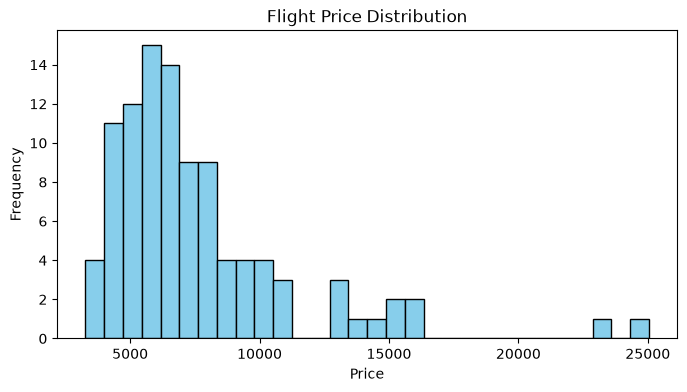

In [1068]:
plt.figure(figsize=(8,4))
plt.hist(df['Price_INR'],bins=30,color='skyblue',edgecolor='black')
plt.title('Flight Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

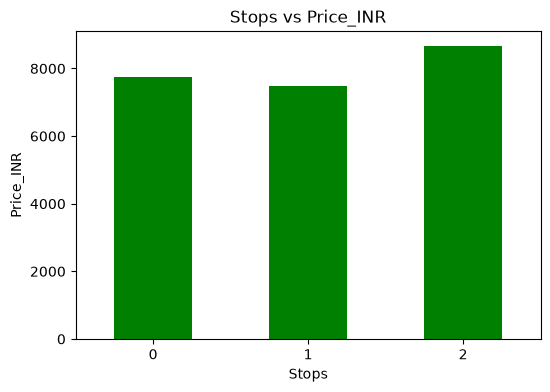

In [1069]:
plt.figure(figsize=(6,4))
df.groupby('Stops')['Price_INR'].mean().plot(kind='bar',color='green')
plt.title('Stops vs Price_INR')
plt.xlabel('Stops')
plt.ylabel('Price_INR')
plt.xticks(rotation=0)
plt.show()

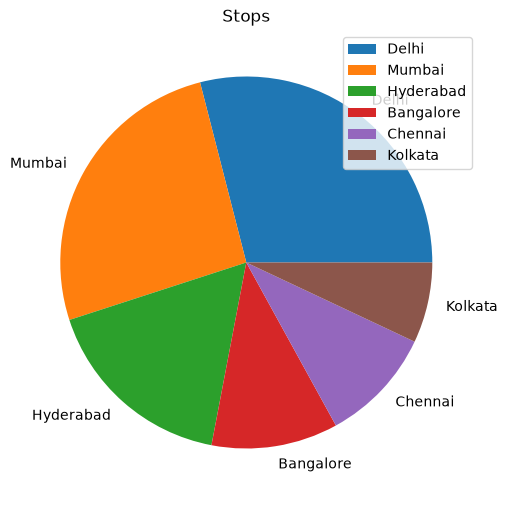

In [1070]:
plt.figure(figsize=(6,7))
df['Source'].value_counts().plot(kind='pie')
plt.title('Stops')
plt.legend()
plt.show()

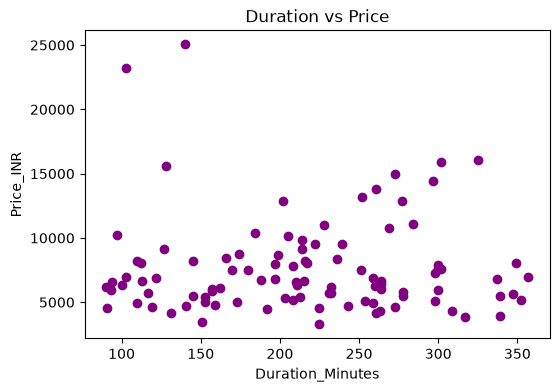

In [1071]:
plt.figure(figsize=(6,4))
plt.scatter(df['Duration_Minutes'],df['Price_INR'],color='purple')
plt.title('Duration vs Price')
plt.xlabel('Duration_Minutes')
plt.ylabel('Price_INR')
plt.show()

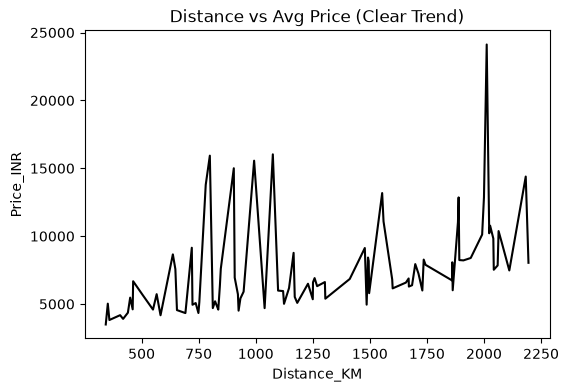

In [1072]:
plt.figure(figsize=(6,4))
df.groupby('Distance_KM')['Price_INR'].mean().plot(color='black')
plt.title('Distance vs Avg Price (Clear Trend)')
plt.xlabel('Distance_KM')
plt.ylabel('Price_INR')
plt.show()



In [1073]:
import sklearn

In [1074]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Airline_Encoded']=le.fit_transform(df['Airline'])
print(df[['Airline','Airline_Encoded']].head())
df['Source_Encoded']=le.fit_transform(df['Source'])

     Airline  Airline_Encoded
0     IndiGo                2
1  Air India                0
2  Air India                0
3   Go First                1
4  Air India                0


In [1075]:
from sklearn.preprocessing import OrdinalEncoder
class_order = [['Economy', 'Premium Economy', 'Business', 'First']]
oe = OrdinalEncoder(categories=class_order)
df['Class_Encoded'] = oe.fit_transform(df[['Class']])
print(df[['Class', 'Class_Encoded']].head())
df['Stops_Encoded'] = df['Stops'].astype(int)
print(df[['Stops', 'Stops_Encoded']].head())

             Class  Class_Encoded
0          Economy            0.0
1          Economy            0.0
2          Economy            0.0
3         Business            2.0
4  Premium Economy            1.0
   Stops  Stops_Encoded
0      0              0
1      1              1
2      0              0
3      0              0
4      1              1
